In [1]:
# import
import os, sys, platform
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
from brainsmash.mapgen.base import Base
from scipy.spatial import distance
from tqdm import tqdm

# import plotting libraries
import matplotlib.pyplot as plt

In [2]:
# import functions from snaplab tools
os_name = platform.system()
print(f"Current OS is: {os_name}")

if os_name == "Linux":
    sys.path.extend([r'/home/lindenmp/research_projects/snaplab_tools'])
elif os_name == "Darwin":
    sys.path.extend([r'/Users/lindenmp/research_projects/snaplab_tools'])
from snaplab_tools.plotting.plotting import plot_correlation, plot_correlation_unity
from snaplab_tools.nulls.utils import get_null_p
from snaplab_tools.plotting.plotting import null_plot

Current OS is: Darwin


# Load data

First, let's load some data from the HCP. 

We will load a pair of vectors that encode some brain data. The first will be a vector of intracortical myelin content; this is extracted from the T1w/T2w ratio. The second will be a vector of intrinsic neural time scales; this is extracted by quantifying the decay of an autocorrelation function fit to regional resting-state fMRI time series.

Note, this data is not provided with this tutorial. If you want to execute this notebook, you will need to provide your own data.

In [3]:
# directory where data is stored
if os_name == "Linux":
    in_dir = '/home/lindenmp/research_projects/nct_xr/data'
elif os_name == "Darwin":
    in_dir = '/Users/lindenmp/Google-Drive-Personal/work/data'

myelin_file = os.path.join(in_dir, 'hcp_schaefer400-7_myelin.npy')
myelin = np.mean(np.load(myelin_file), axis=1)
print(myelin.shape)

rsacf_file = os.path.join(in_dir, 'hcp_schaefer400-7_rsacf.npy')
rsacf = np.mean(np.load(rsacf_file)[:, 0, :], axis=1)
print(rsacf.shape)

(400,)
(400,)


We'll also load some data about parcellation (we'll use this later)

In [4]:
# Load parcellation data
parc_file = os.path.join(in_dir, 'Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv')
parc = pd.read_csv(parc_file, header=0, names=['ROI_Label', 'ROI_Name', 'R', 'A', 'S'], index_col=1)
parc.drop(columns=['ROI_Label'], inplace=True)
parc.head()

,R,A,S
ROI_Name,,,
7Networks_LH_Vis_1,-33,-42,-21
7Networks_LH_Vis_2,-30,-33,-18
7Networks_LH_Vis_3,-36,-62,-17
7Networks_LH_Vis_4,-24,-55,-8
7Networks_LH_Vis_5,-23,-73,-10


In [5]:
# Extract Yeo systems
yeo_systems = parc.index
yeo_systems = yeo_systems.str.replace('7Networks_LH_', '')
yeo_systems = yeo_systems.str.replace('7Networks_RH_', '')
yeo_systems = [i.split('_')[0] for i in yeo_systems]
yeo_systems = [i.split(' ')[1] for i in yeo_systems]
print(yeo_systems)

['Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'Vis', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'SomMot', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'DorsAttn', 'SalVentAttn', 'SalVentAttn', 'SalVentAttn', 'SalVentAttn', 'SalVentAttn', 'SalVentAttn', 'SalVentAttn', 'SalVentAttn', 'SalVentAttn', '

# Plot correlation

Now let's plot a basic correlation

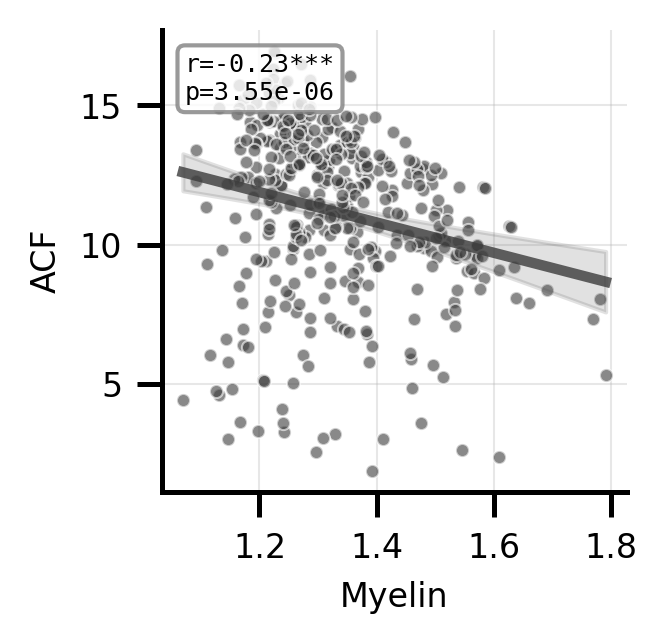

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(2, 2), dpi=300)
plot_correlation(myelin, rsacf, axes, x_label='Myelin', y_label='ACF', fontsize=8)
plt.show()

The function plots a Pearson correlation by default, but you can annotate it with Spearman instead

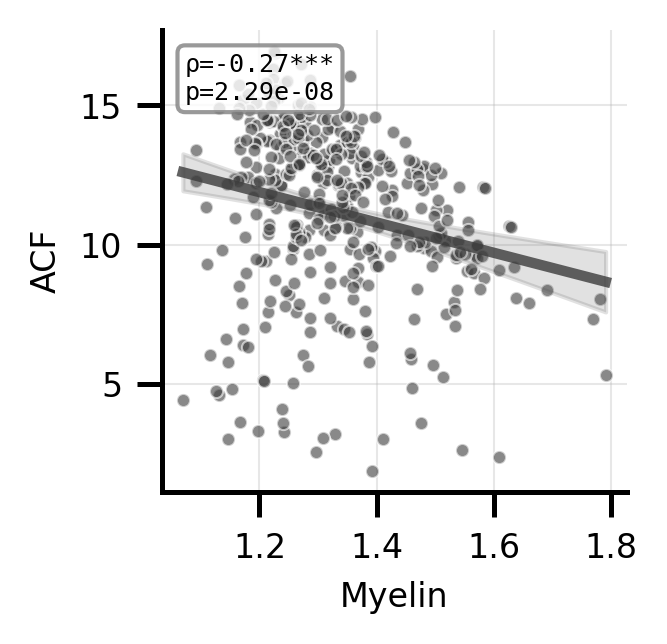

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(2, 2), dpi=300)
plot_correlation(myelin, rsacf, axes, x_label='Myelin', y_label='ACF', fontsize=8,
                 method='spearman') # fit spearman instead of pearson
plt.show()

You can also use this function to do some simple polynomial fitting

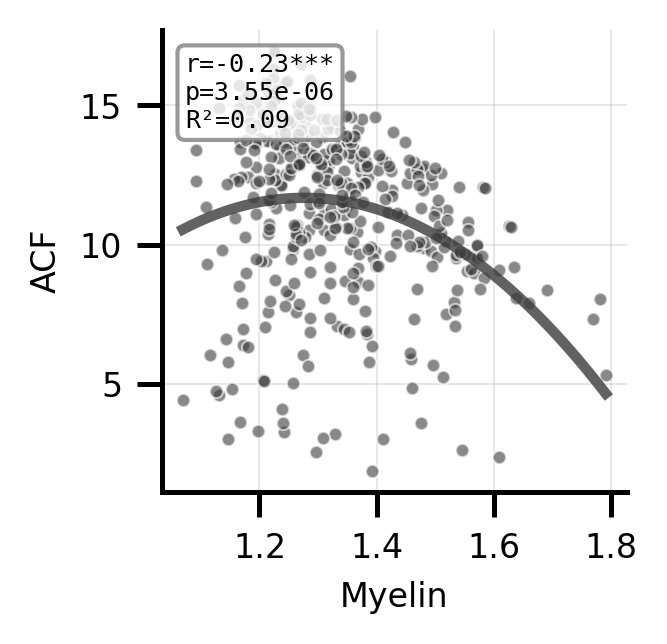

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(2, 2), dpi=300)
plot_correlation(myelin, rsacf, axes, x_label='Myelin', y_label='ACF', fontsize=8,
                 auto_polynomial=True, models_to_test=[1, 2]) # fit polynomial of order 1 and 2
plt.show()

Finally, you can color the points in the plot using a set of categorical labels of your choosing. Let's demonstrate using the Yeo systems we extracted from our parcellation data above

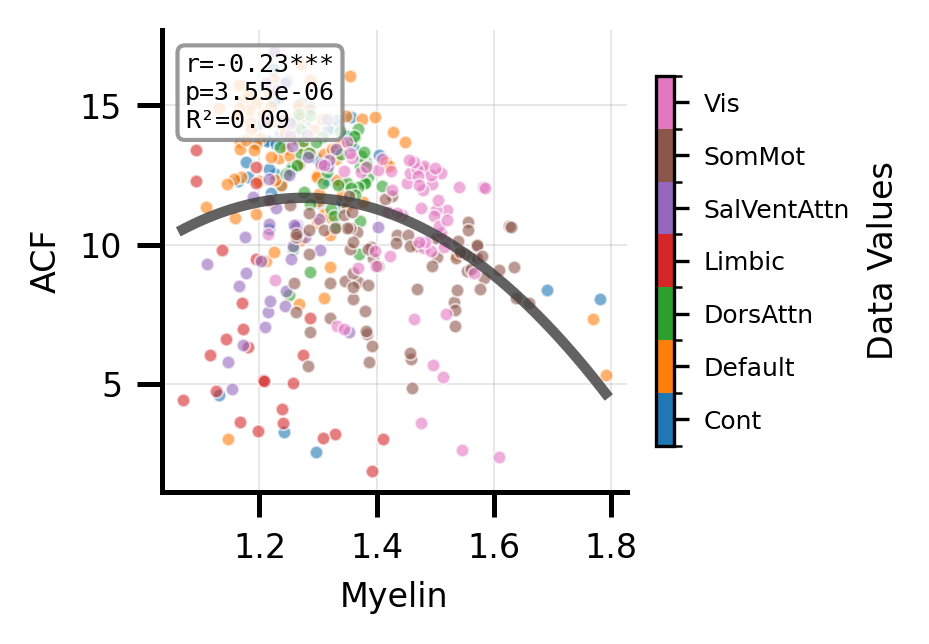

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(2.5, 2), dpi=300)
plot_correlation(myelin, rsacf, axes, x_label='Myelin', y_label='ACF', fontsize=8,
                 auto_polynomial=True, models_to_test=[1, 2],
                 data_group=yeo_systems)
plt.show()

## Embedding a permutation-based null

Finally, you can use an empirical null to assign a custom p-value and embed the corresponding null.

We'll start by running our null.

In [10]:
# define distance matrix
distance_matrix = distance.pdist(
    parc, "euclidean"
)  # get euclidean distances between nodes
distance_matrix = distance.squareform(distance_matrix)  # reshape to square matrix

# run BrainSMASH
np.random.seed(0)
n_perms = 1000
base = Base(x=myelin, D=distance_matrix)
myelin_null_maps = base(n=n_perms)
print(myelin_null_maps.shape)

(1000, 400)


In [11]:
null_distribution = np.zeros(n_perms)
for i in tqdm(np.arange(n_perms)):
    null_distribution[i] = sp.stats.spearmanr(myelin_null_maps[i], rsacf)[0]

100%|██████████| 1000/1000 [00:00<00:00, 7377.23it/s]


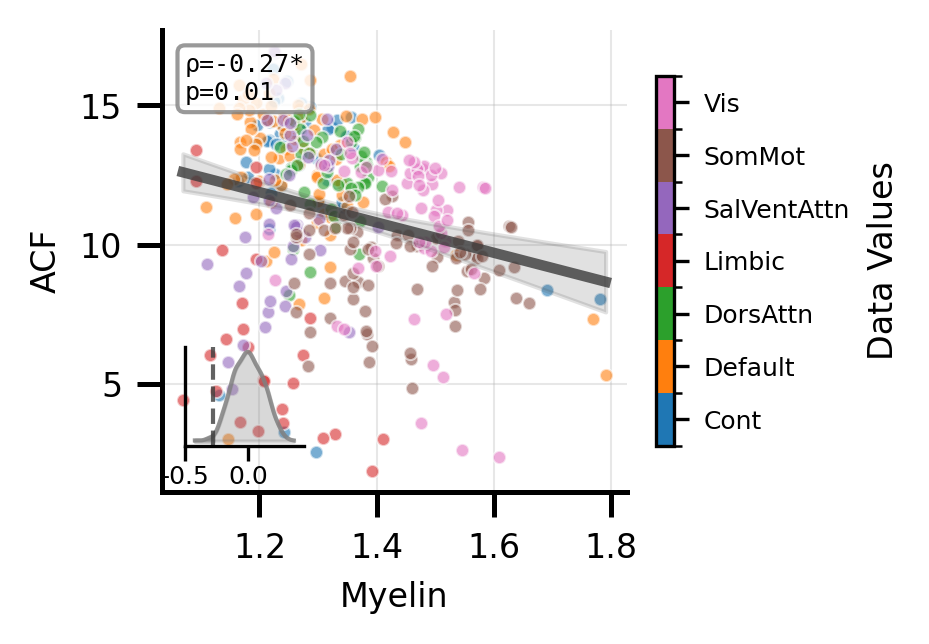

In [12]:
custom_inset = {
    # 'custom_pvalue': 0.1,
    'custom_null': null_distribution
}

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(2.5, 2), dpi=300)
plot_correlation(myelin, rsacf, axes, x_label='Myelin', y_label='ACF', fontsize=8, method='spearman',
                 data_group=yeo_systems,
                 custom_inset=custom_inset
                 )
plt.show()

## Alternative: unity plots

Another version of a correlation plot that can be informative in certain situations is a `unity plot`. This is a special version of a correlation plot where the axes are scaled such that `X=Y` is positioned along the diagonal of the plot space. This allows you to easily visual whether `X>Y` or `X<Y`. 

Note, this type of plot *only* makes sense if you expect that values across your two input variables could be the same. As such, you wouldn't use this to plot the correlation between two independent variables, as shown above. Instead, you'd use it to plot two variables with known dependencies (e.g., an experimental manipulation on the *same* variable).

Let's see what that looks like!

In [13]:
data = pd.read_csv(os.path.join(in_dir, 'data.csv'), index_col=0)
data.head()

,Myelin_Rest,Myelin_Movies,Myelin_Tasks,SC_Strength_Rest,SC_Strength_Movies,SC_Strength_Tasks
subject_ids,,,,,,
100610,-0.315018,-0.225163,-0.241266,-0.006342,-0.106441,0.028421
102311,-0.240422,-0.356941,-0.456335,0.088003,0.026684,-0.094972
102816,-0.429234,-0.116425,-0.247045,0.102717,0.026733,0.082442
104416,-0.408636,-0.141626,-0.079850,0.181252,0.065049,0.036368
105923,-0.212734,-0.332650,-0.211384,0.093719,-0.033972,-0.079691


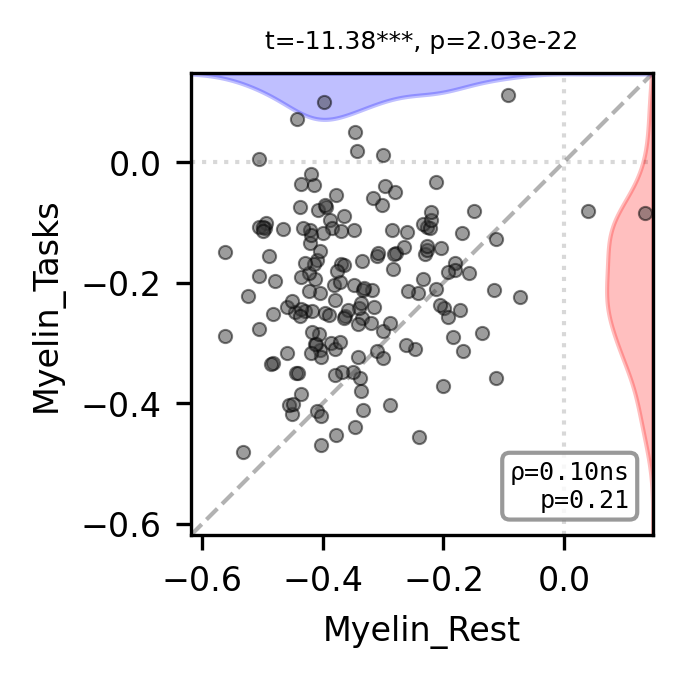

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(2, 2), dpi=300)
plot_correlation_unity(data['Myelin_Rest'], data['Myelin_Tasks'], axes, fontsize=8, grid=False,
                       correlation_type='spearman', show_correlation=True, show_marginals=True)
plt.show()

Each point in this plot is a subject, rather than a region, and each value is the correlation between that subject's myelin and either their resting-state or task-based fMRI. This rest *vs.* task difference is the experimental manipulation mentioned above.

The `unity plot` illustrates that there is a systematic effect here, wherein most subjects not only lie off the diagonal (i.e., `Myelin_Rest != Myelin_Tasks`) but they do so in one direction (`Myelin_Tasks > Myelin_Rest`).